## This notebook explores the concept of using gradient direction as a measure of diversity to enable batch sampling strategies which select points with high uncertainty, but which are not similar in their gradient directions  

## Model / Problem Definition 

In [3]:
from uqregressors.conformal import cqr 
import sys 
import os 
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path: 
    sys.path.append(project_root)

from UBAS.generators.central_peak_generator import CentralPeakGenerator
from UBAS.generators.input_generator import InputGenerator 
import torch 
import torch.nn as nn 
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

class RegressionNN(nn.Module): 
    def __init__(self, input_dim, hidden_dim=32, epochs=100, lr=0.001, batch_size=32, verbose=True, device=None, random_seed=42, loss_fn = F.mse_loss): 
        super(RegressionNN, self).__init__() 
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1)
        self.epochs = epochs 
        self.lr = lr 
        self.batch_size = batch_size 
        self.verbose = verbose
        self.device = device or ('cuda' if torch.cuda.is_available() else 'cpu')
        self.random_seed = random_seed
        self.loss_fn = loss_fn
        self.to(self.device)

    def forward(self, x): 
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x 
    
    def fit(self, X, y): 
        torch.manual_seed(self.random_seed)
        X_tensor = torch.tensor(X, dtype=torch.float32)
        y_tensor = torch.tensor(y, dtype=torch.float32).view(-1, 1)

        dataset = TensorDataset(X_tensor, y_tensor)
        dataloader = DataLoader(dataset, batch_size=self.batch_size, shuffle=True)

        optimizer = torch.optim.Adam(self.parameters(), lr=self.lr)
        loss_fn = self.loss_fn

        self.train() 
        for epoch in range(self.epochs): 
            epoch_loss = 0.0
            for batch_X, batch_y in dataloader: 
                batch_X, batch_y = batch_X.to(self.device), batch_y.to(self.device)

                optimizer.zero_grad() 
                outputs = self.forward(batch_X)
                loss = loss_fn(outputs, batch_y)
                loss.backward() 
                optimizer.step() 

                epoch_loss += loss.item() 

            if self.verbose and (epoch + 1) % 10 == 0: 
                print(f"Epoch {epoch+1}/{self.epochs}, Loss: {epoch_loss/len(dataloader):.4f}")

    def predict(self, X): 
        self.eval() 
        with torch.no_grad(): 
            X_tensor = torch.tensor(X, dtype=torch.float32).to(self.device)
            outputs = self.forward(X_tensor)
            return outputs.cpu().numpy().flatten()
        
    def compute_last_layer_grads(self, x_new, y_true):
        self.train() 
        self.zero_grad() 
        x_tensor = torch.tensor(x_new, dtype=torch.float32, requires_grad=True).to(self.device)
        y_tensor = torch.tensor(y_true, dtype=torch.float32).view(-1, 1).to(self.device)
        output = self(x_tensor)
        loss = (self.loss_fn(output, y_tensor))
        loss.backward() 

        grad_weight = self.fc2.weight.grad.detach().cpu().clone() 
        grad_bias = self.fc2.bias.grad.detach().cpu().clone() 

        return grad_weight, grad_bias 
    

Epoch 10/300, Loss: 0.0653
Epoch 20/300, Loss: 0.0218
Epoch 30/300, Loss: 0.0039
Epoch 40/300, Loss: 0.0030
Epoch 50/300, Loss: 0.0013
Epoch 60/300, Loss: 0.0009
Epoch 70/300, Loss: 0.0006
Epoch 80/300, Loss: 0.0005
Epoch 90/300, Loss: 0.0004
Epoch 100/300, Loss: 0.0004
Epoch 110/300, Loss: 0.0004
Epoch 120/300, Loss: 0.0004
Epoch 130/300, Loss: 0.0003
Epoch 140/300, Loss: 0.0003
Epoch 150/300, Loss: 0.0003
Epoch 160/300, Loss: 0.0003
Epoch 170/300, Loss: 0.0003
Epoch 180/300, Loss: 0.0003
Epoch 190/300, Loss: 0.0003
Epoch 200/300, Loss: 0.0003
Epoch 210/300, Loss: 0.0003
Epoch 220/300, Loss: 0.0003
Epoch 230/300, Loss: 0.0003
Epoch 240/300, Loss: 0.0003
Epoch 250/300, Loss: 0.0003
Epoch 260/300, Loss: 0.0003
Epoch 270/300, Loss: 0.0003
Epoch 280/300, Loss: 0.0003
Epoch 290/300, Loss: 0.0002
Epoch 300/300, Loss: 0.0002


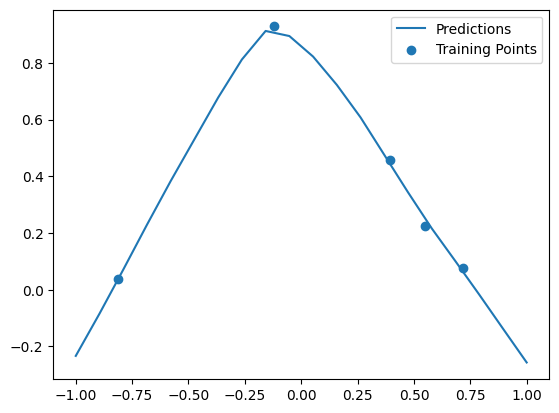

In [4]:
import numpy as np 
import matplotlib.pyplot as plt

ndim = 1 
init_points = 5 
hidden_dim = 100

bounds = np.ones((2, ndim)) * np.array([[-1, 1]]).T 
input_sampler = InputGenerator(bounds, ndim, seed=42)
init_inputs, init_targets = CentralPeakGenerator(-5).generate(input_sampler.uniformly_sample(init_points))

mse_net = RegressionNN(ndim, hidden_dim=hidden_dim, epochs=300, lr=0.01, batch_size=32, loss_fn=F.mse_loss) 
mse_net.fit(init_inputs, init_targets)

def plot_fit(net, X_train=init_inputs, y_train=init_targets): 
    x_test = np.linspace(-1, 1, 20).reshape(-1, 1)
    y_preds = net.predict(x_test)
    plt.figure() 
    if isinstance(y_preds, tuple): 
        mean = y_preds[0]
        lower = y_preds[1]
        upper = y_preds[2]
        plt.plot(x_test, mean, label='Predictions')
        plt.plot(x_test, lower, linestyle="--", color="black", label="90% CI")
        plt.plot(x_test, upper, linestyle="--", color="black")
    else: 
        plt.plot(x_test, y_preds, label='Predictions')
    plt.scatter(X_train, y_train, label='Training Points')
    plt.legend() 
    plt.show() 

plot_fit(mse_net)

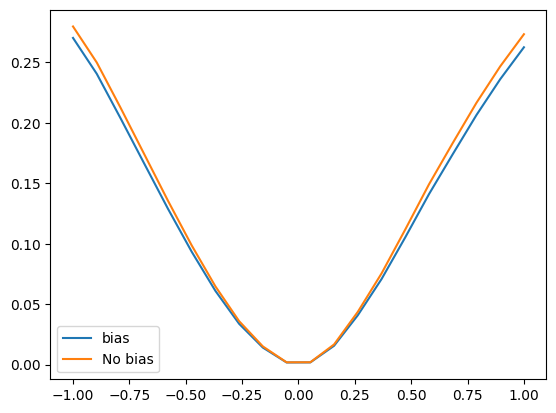

In [151]:
def compute_normalized_grads(net, x_new=0, epsilon=1e-6):
    x_new = [[x_new]]
    y_true = net.predict(x_new) + epsilon

    grad_w, grad_b = net.compute_last_layer_grads(x_new, y_true)

    #print("Gradient w.r.t. fc2 weights:", grad_w / torch.linalg.norm(grad_w))
    #print("Gradient w.r.t. fc2 bias:", grad_b)

    overall_gradient = torch.hstack([grad_w[0].view(1, -1).squeeze(), grad_b[0].squeeze()])
    #print("Normalized gradient: eps = -1e-6", overall_gradient / torch.linalg.norm(overall_gradient))

    y_true_larger_eps = net.predict(x_new) - 1e3 * epsilon 
    grad_w_l, grad_b_l = net.compute_last_layer_grads(x_new, y_true_larger_eps)
    overall_gradient_l = torch.hstack([grad_w_l[0].view(1, -1).squeeze(), grad_b_l[0].squeeze()])
    #print("Normalized gradient: eps = 1e-3", overall_gradient_l / torch.linalg.norm(overall_gradient_l))

    #print("Gradient dot product")
    #print(torch.dot(overall_gradient, overall_gradient_l) / (torch.linalg.norm(overall_gradient) * torch.linalg.norm(overall_gradient_l)))
    return(overall_gradient)

def compute_cosine_similarity(net, point_1, point_2, include_bias=True): 
    epsilon = 1e-6 

    x_1 = [[point_1]]
    x_2 = [[point_2]]

    y_new_1 = net.predict(x_1) + epsilon 
    y_new_2 = net.predict(x_2) + epsilon 

    grad_w_1, grad_b_1 = net.compute_last_layer_grads(x_1, y_new_1)
    grad_w_2, grad_b_2 = net.compute_last_layer_grads(x_2, y_new_2)

    if include_bias: 
        overall_grad_1 = torch.hstack([grad_w_1[0].view(1, -1).squeeze(), grad_b_1[0].squeeze()])
        overall_grad_2 = torch.hstack([grad_w_2[0].view(1, -1).squeeze(), grad_b_2[0].squeeze()])

    else: 
        overall_grad_1 = grad_w_1[0].view(1, -1).squeeze() 
        overall_grad_2 = grad_w_2[0].view(1, -1).squeeze() 

    #print("Distance Gradient Dot Product") 
    dotted = torch.dot(overall_grad_1, overall_grad_2) / (torch.linalg.norm(overall_grad_1) * torch.linalg.norm(overall_grad_2))
    return dotted 

def plot_cosine_similarities(net): 
    initial_point = 0 
    comparison_points = np.linspace(-1, 1, 20)
    bias_similarities = []
    no_bias_similarities = [] 
    for c in comparison_points: 

        bias_similarity = (1 - compute_cosine_similarity(net, initial_point, c, True))
        no_bias_similarity = (1 - compute_cosine_similarity(net, initial_point, c, False)) 

        bias_similarities.append(bias_similarity)
        no_bias_similarities.append(no_bias_similarity)

    plt.figure() 
    plt.plot(comparison_points, bias_similarities, label='bias')
    plt.plot(comparison_points, no_bias_similarities, label='No bias')
    plt.legend() 
    plt.show()

compute_normalized_grads(mse_net)
compute_cosine_similarity(mse_net, -0.5, 1, True)
plot_cosine_similarities(mse_net)

## A key takeaway is that the gradient direction remains constant no matter the value of epsilon chosen (for MSE loss). Now, let's investigate the pinball loss. 

Epoch 10/100, Loss: 0.1207
Epoch 20/100, Loss: 0.1068
Epoch 30/100, Loss: 0.0700
Epoch 40/100, Loss: 0.0405
Epoch 50/100, Loss: 0.0218
Epoch 60/100, Loss: 0.0147
Epoch 70/100, Loss: 0.0102
Epoch 80/100, Loss: 0.0088
Epoch 90/100, Loss: 0.0078
Epoch 100/100, Loss: 0.0053


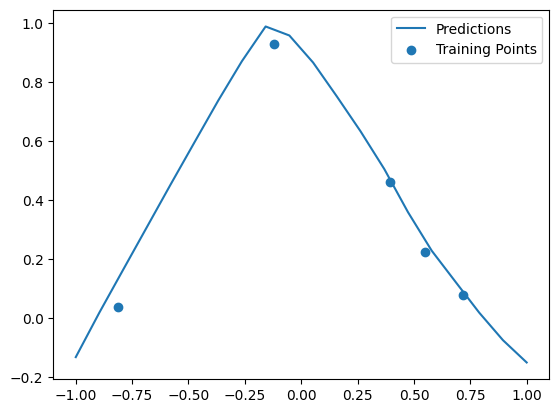

In [182]:
def pinball_loss(y_pred, y_true, tau=0.9): 
    error = y_true - y_pred 
    loss = torch.max(tau * error, (tau-1) * error) 
    return torch.mean(loss)

pinball_net = RegressionNN(ndim, hidden_dim=hidden_dim, epochs=100, lr=0.01, batch_size=32, loss_fn=pinball_loss)
pinball_net.fit(init_inputs, init_targets)

plot_fit(pinball_net)

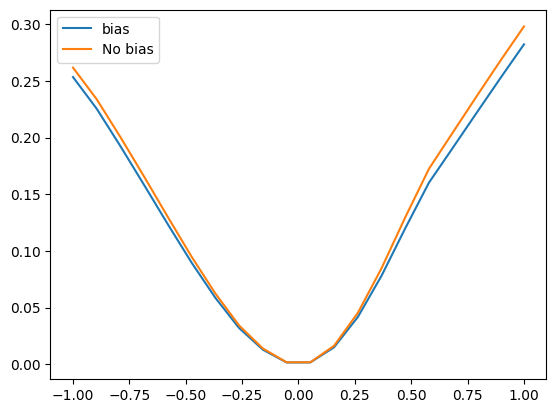

In [183]:
compute_normalized_grads(pinball_net)
plot_cosine_similarities(pinball_net)

## Now let's try NLL loss for predicted sigma and mu

In [ ]:
class NLL_NN(nn.Module): 
    def __init__(self, input_dim, hidden_dim=32, epochs=100, lr=0.001, batch_size=32, verbose=True, device=None, random_seed=42): 
        super(NLL_NN, self).__init__() 
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 2)
        self.epochs = epochs 
        self.lr = lr 
        self.batch_size = batch_size 
        self.verbose = verbose
        self.device = device or ('cuda' if torch.cuda.is_available() else 'cpu')
        self.random_seed = random_seed
        self.to(self.device)

    def forward(self, x): 
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        means = x[:, 0]
        variances = x[:, 1]
        scaled_variance = F.softplus(variances) + 1e-6 
        scaled_outputs = torch.cat((means.unsqueeze(dim=1), scaled_variance.unsqueeze(dim=1)), dim=1)

        return scaled_outputs 
    
    def nll_loss(self, preds, y): 
        means = preds[:, 0]
        variances = preds[:, 1]
        precision = 1 / variances
        squared_error = (y.view(-1) - means) ** 2 
        nll = 0.5 * (torch.log(variances) + precision * squared_error)
        return nll.mean()

    def fit(self, X, y): 
        torch.manual_seed(self.random_seed)
        X_tensor = torch.tensor(X, dtype=torch.float32)
        y_tensor = torch.tensor(y, dtype=torch.float32).view(-1, 1)

        dataset = TensorDataset(X_tensor, y_tensor)
        dataloader = DataLoader(dataset, batch_size=self.batch_size, shuffle=True)

        optimizer = torch.optim.Adam(self.parameters(), lr=self.lr)
        loss_fn = self.nll_loss

        self.train() 
        for epoch in range(self.epochs): 
            epoch_loss = 0.0
            for batch_X, batch_y in dataloader: 
                batch_X, batch_y = batch_X.to(self.device), batch_y.to(self.device)

                optimizer.zero_grad() 
                outputs = self.forward(batch_X)
                loss = loss_fn(outputs, batch_y)
                loss.backward() 
                optimizer.stpe() 

                epoch_loss += loss.item() 

            if self.verbose and (epoch + 1) % 10 == 0: 
                print(f"Epoch {epoch+1}/{self.epochs}, Loss: {epoch_loss/len(dataloader):.4f}")

    def predict(self, X): 
        self.eval() 
        with torch.no_grad(): 
            X_tensor = torch.tensor(X, dtype=torch.float32).to(self.device)
            outputs = self.forward(X_tensor)
            return outputs[:, 0].cpu().numpy().flatten()
        
    def compute_last_layer_grads(self, x_new, y_true):
        self.train() 
        self.zero_grad() 
        x_tensor = torch.tensor(x_new, dtype=torch.float32, requires_grad=True).to(self.device)
        y_tensor = torch.tensor(y_true, dtype=torch.float32).view(-1, 1).to(self.device)
        output = self(x_tensor)
        loss = (self.nll_loss(output, y_tensor))
        loss.backward() 

        grad_weight = self.fc2.weight.grad.detach().cpu().clone() 
        grad_bias = self.fc2.bias.grad.detach().cpu().clone() 

        return grad_weight, grad_bias 
    

Epoch 10/100, Loss: -0.7409
Epoch 20/100, Loss: -1.7003
Epoch 30/100, Loss: -2.6374
Epoch 40/100, Loss: -2.9046
Epoch 50/100, Loss: -1.5865
Epoch 60/100, Loss: -3.0240
Epoch 70/100, Loss: -3.2422
Epoch 80/100, Loss: -2.9627
Epoch 90/100, Loss: -2.7159
Epoch 100/100, Loss: -3.0704


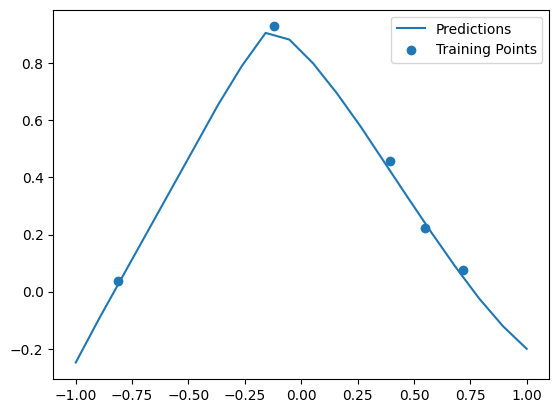

In [185]:
nll_net = NLL_NN(ndim, hidden_dim=hidden_dim, epochs=100, lr=0.01, batch_size=32)
nll_net.fit(init_inputs, init_targets)

plot_fit(nll_net)

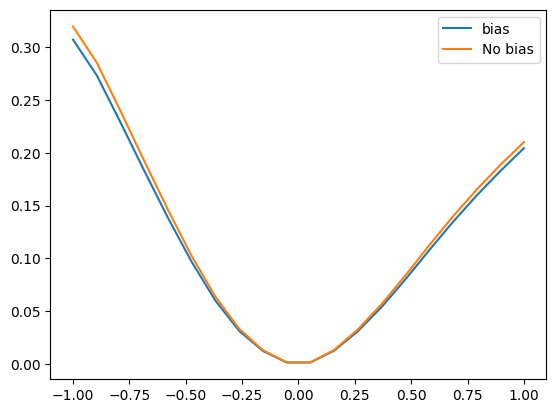

In [186]:
compute_normalized_grads(nll_net)
plot_cosine_similarities(nll_net)

In [156]:
import torch 

def compute_normalized_grad(net, x_new, epsilon=1e-6):
    x_new = [[x_new]]
    y_true = net.predict(x_new) + epsilon
    grad_w, grad_b = net.compute_last_layer_grads(x_new, y_true)

    grad_vec = torch.hstack([grad_w[0].flatten(), grad_b[0].flatten()])
    grad_vec = grad_vec / (torch.norm(grad_vec) + 1e-8)
    return grad_vec


def orthogonal_component(g_x, G_selected):
    if len(G_selected) == 0:
        return g_x
    G = torch.stack(G_selected)  # shape (k, d)
    Q, _ = torch.linalg.qr(G.T, mode='reduced')  # Q: d x k
    proj = Q @ (Q.T @ g_x)
    residual = g_x - proj
    return residual


def plot_iteration(candidate_X, acquisition_scores, selected_idx, net,
                   train_X, train_y, candidate_X_selected_indices, title=""):
    candidate_X = candidate_X.flatten()

    # Predict NN output over dense grid
    grid = np.linspace(-1, 1, 200).reshape(-1, 1)
    preds = net.predict(grid)

    fig, axs = plt.subplots(1, 2, figsize=(12, 4))

    # Acquisition Function Plot
    axs[0].plot(candidate_X, acquisition_scores, label="Acquisition Score")
    axs[0].scatter(candidate_X[selected_idx], acquisition_scores[selected_idx],
                   color='red', label='Current Selected Point')
    axs[0].set_title("Acquisition Function")
    axs[0].legend()
    axs[0].set_xlabel("Input x")
    axs[0].set_ylabel("Acquisition Score")

    # Neural Net Prediction Plot
    axs[1].plot(grid, preds, label="NN Prediction", color='blue')

    axs[1].scatter(train_X, train_y, color='black', label="Training Points")

    # Previously selected candidate points (excluding current one)
    if candidate_X_selected_indices:
        prev_points = [candidate_X[i] for i in candidate_X_selected_indices[:-1]]
        prev_outputs = net.predict(np.array(prev_points).reshape(-1, 1))
        axs[1].scatter(prev_points, prev_outputs,
                       color='purple', marker='x', label="Previously Selected")

    # Currently selected point
    current_x = candidate_X[selected_idx]
    current_y = net.predict([[current_x]])
    axs[1].scatter([current_x], [current_y], color='red', label="Current Selected")

    axs[1].set_title("Neural Network Prediction")
    axs[1].legend()
    axs[1].set_xlabel("Input x")
    axs[1].set_ylabel("Output y")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


def select_batch(net, candidate_X, train_X, train_y, batch_size):
    device = net.device
    candidate_X = torch.tensor(candidate_X, dtype=torch.float32).to(device)
    N = candidate_X.shape[0]

    selected_indices = []
    G_selected = []

    for iter in range(batch_size):
        acquisition_scores = []

        for idx in range(N):
            if idx in selected_indices:
                acquisition_scores.append(float('-inf'))
                continue

            x = candidate_X[idx].item()
            g_x = compute_normalized_grad(net, x)
            residual = orthogonal_component(g_x, G_selected)
            score = torch.norm(residual)
            acquisition_scores.append(score.item())

        acquisition_scores = np.array(acquisition_scores)
        best_idx = int(np.argmax(acquisition_scores))
        selected_indices.append(best_idx)

        # Update selected gradients
        x_sel = candidate_X[best_idx].item()
        g_sel = compute_normalized_grad(net, x_sel)
        G_selected.append(g_sel)

        # Plotting (show all previously selected indices)
        plot_iteration(
            candidate_X.cpu().numpy(),
            acquisition_scores,
            best_idx,
            net,
            train_X,
            train_y,
            selected_indices,
            title=f"Iteration {iter + 1}"
        )

    return selected_indices



In [173]:
def run_adaptive_sampling_round(net, inputs, outputs): 
    # Suppose you have a trained model `mse_net`
    net.fit(inputs, outputs)
    plot_fit(net, X_train=inputs, y_train=outputs)
    
    candidate_X = np.linspace(-1, 1, 100).reshape(-1, 1)  # shape (100, 1)

    selected_idxs = select_batch(net, candidate_X, inputs, outputs, batch_size=10)
    selected_points = candidate_X[selected_idxs]

    print("Selected inputs for labeling:", selected_points)
    selected_xs, selected_ys = CentralPeakGenerator(-5).generate(selected_points)
    post_fit_inputs = np.vstack((inputs.reshape(-1, 1), selected_xs.reshape(-1, 1)))
    post_fit_outputs = np.vstack((outputs.reshape(-1, 1), selected_ys.reshape(-1, 1)))

    return net, post_fit_inputs, post_fit_outputs

Epoch 10/100, Loss: 0.0245
Epoch 20/100, Loss: 0.0007
Epoch 30/100, Loss: 0.0022
Epoch 40/100, Loss: 0.0015
Epoch 50/100, Loss: 0.0006
Epoch 60/100, Loss: 0.0004
Epoch 70/100, Loss: 0.0003
Epoch 80/100, Loss: 0.0003
Epoch 90/100, Loss: 0.0003
Epoch 100/100, Loss: 0.0003


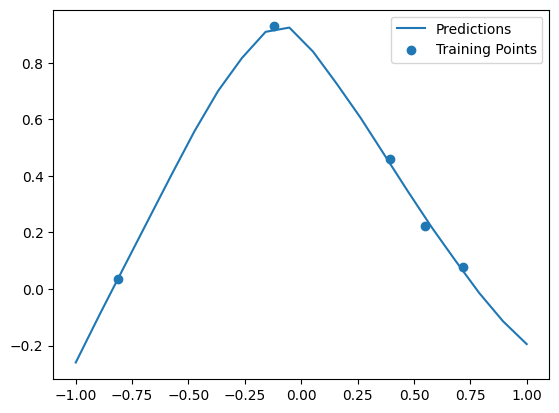

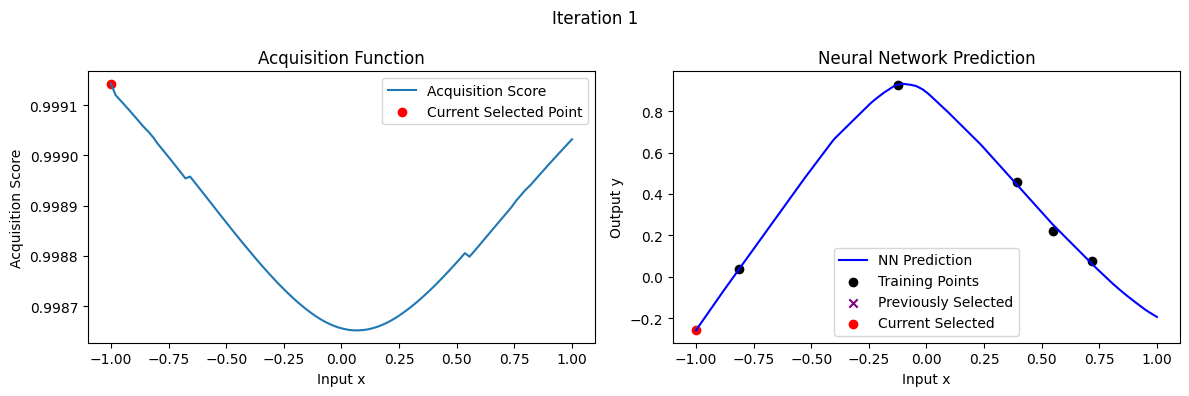

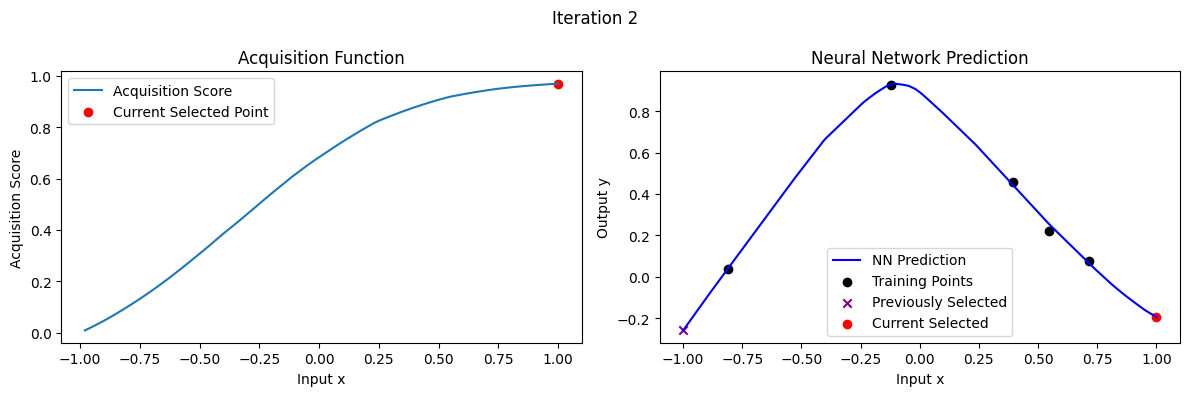

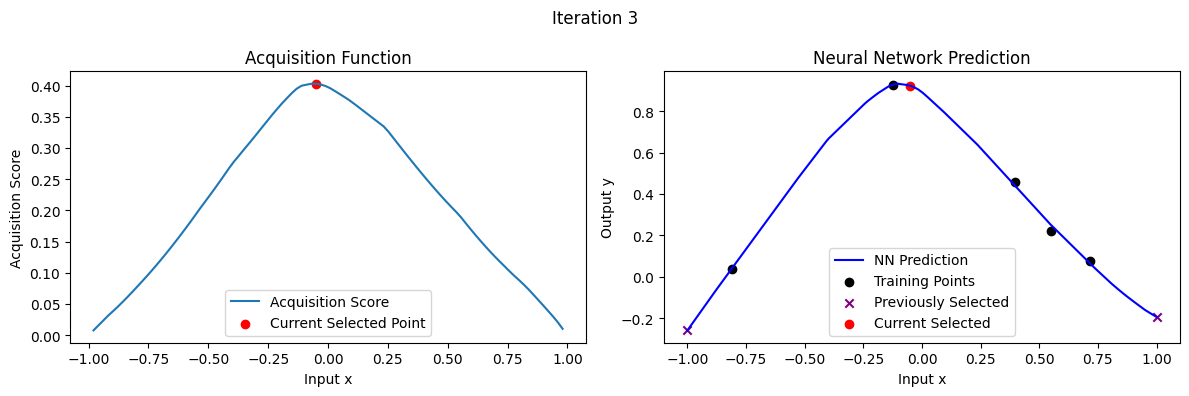

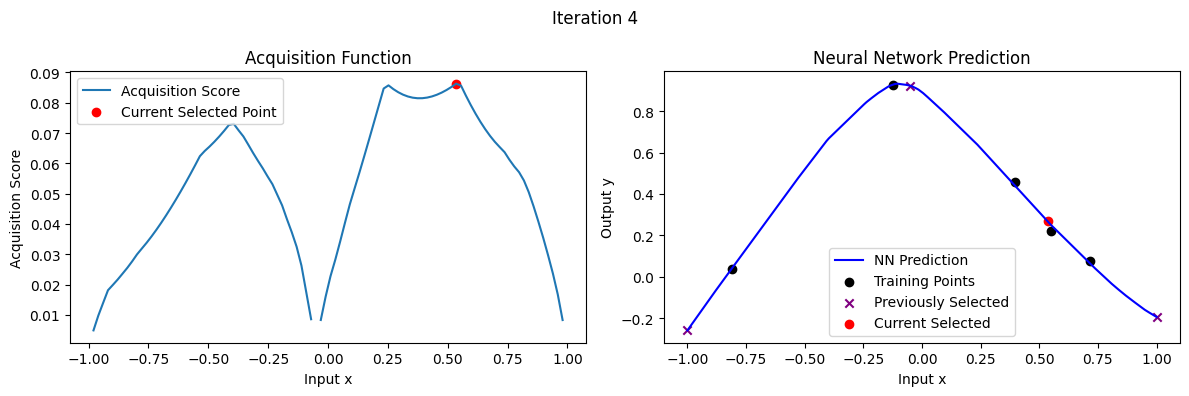

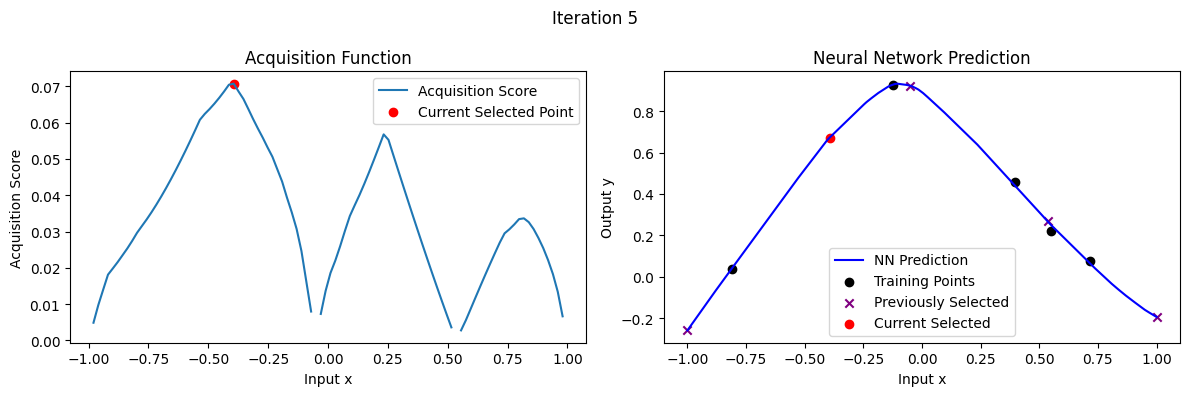

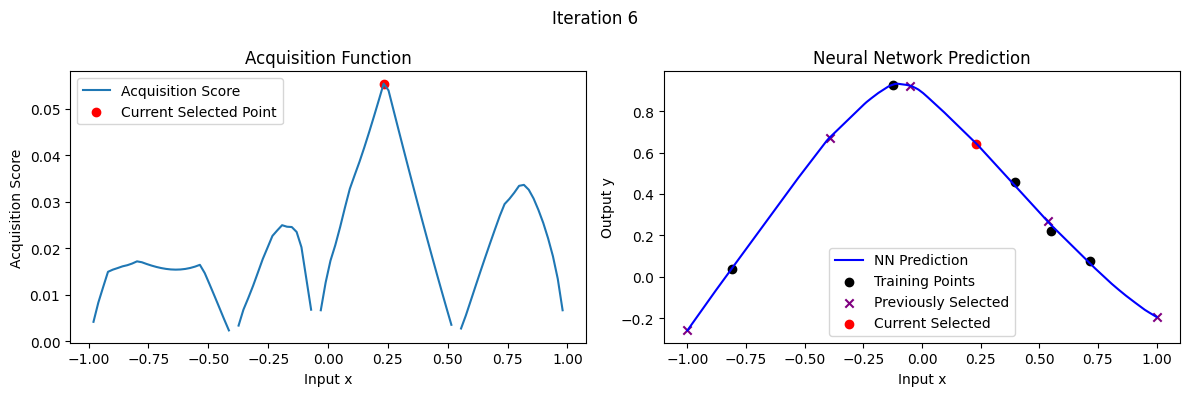

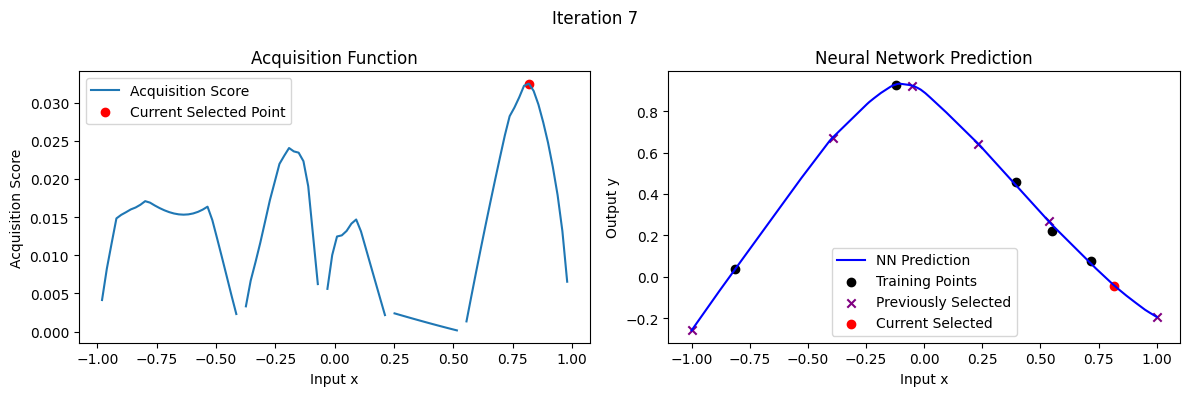

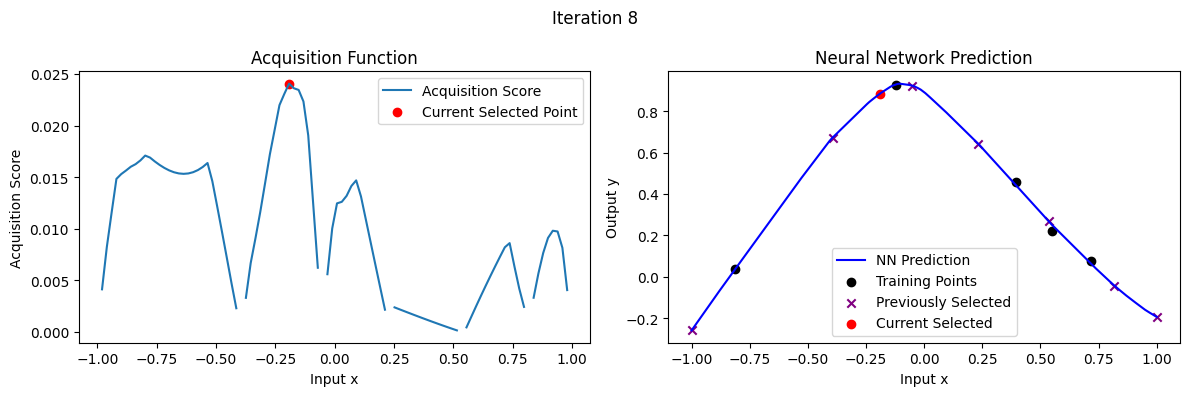

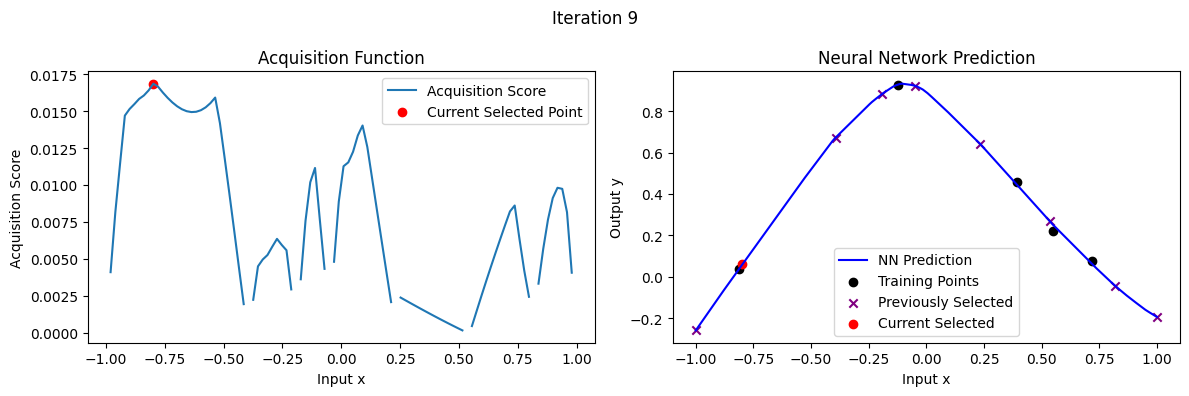

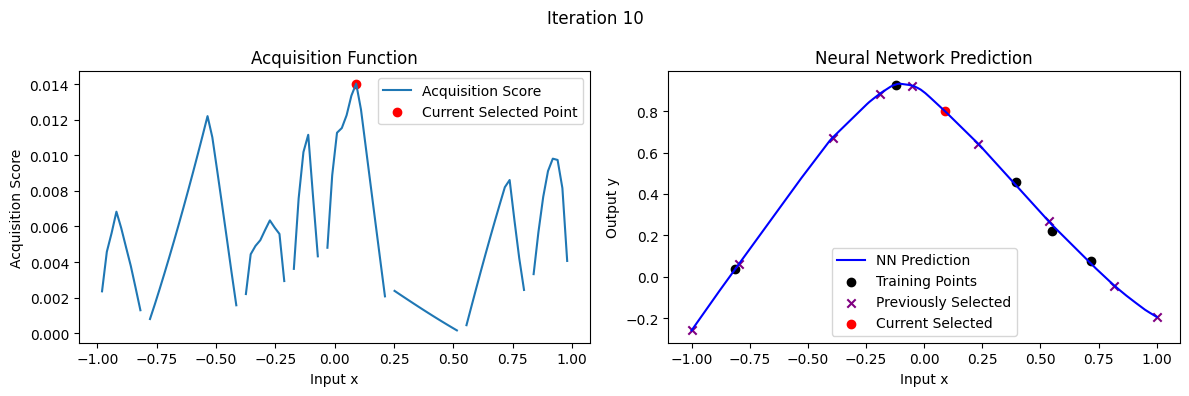

Selected inputs for labeling: [[-1.        ]
 [ 1.        ]
 [-0.05050505]
 [ 0.53535354]
 [-0.39393939]
 [ 0.23232323]
 [ 0.81818182]
 [-0.19191919]
 [-0.7979798 ]
 [ 0.09090909]]


In [174]:
mse_net, round_1_inputs, round_2_outputs = run_adaptive_sampling_round(mse_net, init_inputs, init_targets)

In [ ]:
rounds = 5
adaptive_sampling_inputs = (mse_net, init_inputs, init_targets)

for round in range(rounds): 
    print("Round: ", round)
    adaptive_sampling_inputs = run_adaptive_sampling_round(*adaptive_sampling_inputs)


In [ ]:
rounds = 5
adaptive_sampling_inputs = (pinball_net, init_inputs, init_targets)

for round in range(rounds): 
    print("Round: ", round)
    adaptive_sampling_inputs = run_adaptive_sampling_round(*adaptive_sampling_inputs)

In [ ]:
rounds = 5
adaptive_sampling_inputs = (nll_net, init_inputs, init_targets)

for round in range(rounds): 
    print("Round: ", round)
    adaptive_sampling_inputs = run_adaptive_sampling_round(*adaptive_sampling_inputs)

## Now, let's try with a deep ensemble

[Estimator-0] epoch=0, train_loss=0.5599778890609741, lr=0.001
[Estimator-0] epoch=25, train_loss=-0.21835508942604065, lr=0.001
[Estimator-0] epoch=50, train_loss=-1.8815845251083374, lr=0.001
[Estimator-0] epoch=75, train_loss=-2.6526763439178467, lr=0.001
[Estimator-0] epoch=100, train_loss=-3.437161922454834, lr=0.001
[Estimator-0] epoch=125, train_loss=-3.8251514434814453, lr=0.001
[Estimator-0] epoch=150, train_loss=-3.5494933128356934, lr=0.001
[Estimator-0] epoch=175, train_loss=-3.588754653930664, lr=0.001
[Estimator-0] epoch=200, train_loss=-3.3129630088806152, lr=0.001
[Estimator-0] epoch=225, train_loss=-3.5777671337127686, lr=0.001
[Estimator-0] epoch=250, train_loss=-3.900538206100464, lr=0.001
[Estimator-0] epoch=275, train_loss=-4.269198894500732, lr=0.001
[Estimator-0] epoch=300, train_loss=-4.006512641906738, lr=0.001
[Estimator-0] epoch=325, train_loss=-3.2432332038879395, lr=0.001
[Estimator-0] epoch=350, train_loss=-3.886620044708252, lr=0.001
[Estimator-0] epoch=3

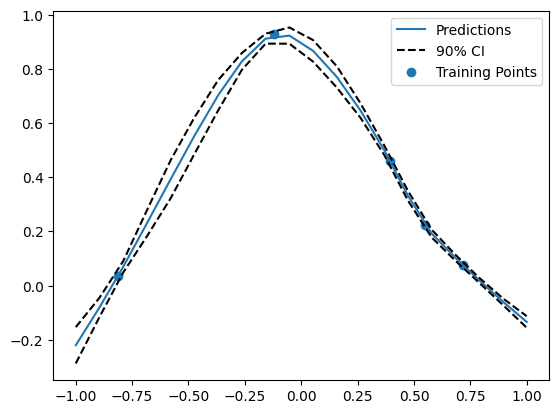

In [5]:
"""
Deep Ensembles
--------------

This module implements Deep Ensemble Regressors for regression of a one dimensional output. 

Key features are: 
    - Customizable neural network architecture 
    - Prediction Intervals based on Gaussian assumption 
    - Parallel training of ensemble members with Joblib
    - Customizable optimizer and loss function
    - Optional Input/Output Normalization
"""

import numpy as np
import torch
import torch.nn as nn
import scipy.stats as st
from joblib import Parallel, delayed
from sklearn.base import BaseEstimator, RegressorMixin 
from uqregressors.utils.activations import get_activation
from uqregressors.utils.logging import Logger
from torch.utils.data import TensorDataset, DataLoader
from pathlib import Path
import json
import pickle
import torch.multiprocessing as mp 
import torch.nn.functional as F
from uqregressors.utils.torch_sklearn_utils import TorchStandardScaler
from uqregressors.utils.data_loader import validate_and_prepare_inputs, validate_X_input

mp.set_start_method('spawn', force=True)

class MLP(nn.Module): 
    """
    A simple multi-layer perceptron which outputs a mean and a positive variance per input sample.
    
    Args:
        input_dim (int): Number of input features.
        hidden_sizes (list of int): List of hidden layer sizes.
        activation (torch.nn.Module): Activation function class (e.g., nn.ReLU).
    """
    def __init__(self, input_dim, hidden_sizes, activation):
        super().__init__()
        layers = []
        for h in hidden_sizes:
            layers.append(nn.Linear(input_dim, h))
            layers.append(activation())
            input_dim = h
        output_layer = nn.Linear(hidden_sizes[-1], 2)
        layers.append(output_layer)
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        outputs = self.model(x)
        means = outputs[:, 0]
        unscaled_variances = outputs[:, 1]
        scaled_variance = F.softplus(unscaled_variances) + 1e-6
        scaled_outputs = torch.cat((means.unsqueeze(dim=1), scaled_variance.unsqueeze(dim=1)), dim=1)

        return scaled_outputs
    
class DeepEnsembleRegressor(BaseEstimator, RegressorMixin): 
    """
    Deep Ensemble Regressor with uncertainty estimation using neural networks.

    Trains an ensemble of MLP models to predict both mean and variance for regression tasks,
    and provides predictive uncertainty intervals.

    Args:
        name (str): Name of the regressor for config files.
        n_estimators (int): Number of ensemble members.
        hidden_sizes (list of int): List of hidden layer sizes for each MLP.
        alpha (float): Significance level for prediction intervals (e.g., 0.1 for 90% interval).
        requires_grad (bool): If True, returned predictions require gradients.
        activation_str (str): Name of activation function to use (e.g., 'ReLU').
        learning_rate (float): Learning rate for optimizer.
        epochs (int): Number of training epochs.
        batch_size (int): Batch size for training.
        optimizer_cls (torch.optim.Optimizer): Optimizer class.
        optimizer_kwargs (dict): Additional kwargs for optimizer.
        scheduler_cls (torch.optim.lr_scheduler._LRScheduler or None): Learning rate scheduler class.
        scheduler_kwargs (dict): Additional kwargs for scheduler.
        loss_fn (callable): Loss function accepting (preds, targets).
        device (str or torch.device): Device to run training on ('cpu' or 'cuda').
        use_wandb (bool): Whether to use Weights & Biases logging.
        wandb_project (str or None): WandB project name.
        wandb_run_name (str or None): WandB run name prefix.
        n_jobs (int): Number of parallel jobs to train ensemble members.
        random_seed (int or None): Seed for reproducibility.
        scale_data (bool): Whether to scale input and output data.
        input_scaler (object or None): Scaler for input features.
        output_scaler (object or None): Scaler for target values.
        defective_models (list): List of model indices to ignore during testing. 
        tuning_loggers (list): List of tuning loggers.
        logging_frequency (int): Number of times to log training results during training.

    Attributes:
        models (list): List of trained PyTorch MLP models.
        input_dim (int): Dimensionality of input features.
        _loggers (list): Training loggers for each model.
        training_logs: Logs from training.
        tuning_logs: Logs from hyperparameter tuning.
        fitted (bool): Whether fit has been successfully called
    """
    def __init__(
        self,
        name = "Deep_Ensemble_Regressor",
        n_estimators=5,
        hidden_sizes=[64, 64],
        alpha=0.1,
        requires_grad=False,
        activation_str="ReLU",
        learning_rate=1e-3,
        epochs=200,
        batch_size=32,
        optimizer_cls=torch.optim.Adam,
        optimizer_kwargs=None,
        scheduler_cls=None,
        scheduler_kwargs=None,
        loss_fn=None,
        device="cpu",
        use_wandb=False,
        wandb_project=None,
        wandb_run_name=None,
        n_jobs=1,
        random_seed=None,
        scale_data=True, 
        input_scaler=None,
        output_scaler=None, 
        defective_models=[], 
        tuning_loggers = [],
        logging_frequency=20, 
    ):
        self.name=name
        self.n_estimators = n_estimators
        self.hidden_sizes = hidden_sizes
        self.alpha = alpha
        self.requires_grad = requires_grad
        self.activation_str = activation_str
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size
        self.optimizer_cls = optimizer_cls
        self.optimizer_kwargs = optimizer_kwargs or {}
        self.scheduler_cls = scheduler_cls
        self.scheduler_kwargs = scheduler_kwargs or {}
        self.loss_fn = loss_fn or self.nll_loss
        self.device = device

        self.use_wandb = use_wandb
        self.wandb_project = wandb_project
        self.wandb_run_name = wandb_run_name

        self.n_jobs = n_jobs
        self.random_seed = random_seed
        self.models = []
        self.input_dim = None

        self.scale_data = scale_data

        if scale_data: 
            self.input_scaler = input_scaler or TorchStandardScaler()
            self.output_scaler = output_scaler or TorchStandardScaler()

        self.defective_models = defective_models
        self._loggers = []
        self.logging_frequency = logging_frequency
        self.training_logs = None
        self.tuning_loggers = tuning_loggers
        self.tuning_logs = None
        self.fitted = False

    def nll_loss(self, preds, y): 
        """
        Negative log-likelihood loss assuming Gaussian outputs.

        Args:
            preds (torch.Tensor): Predicted means and variances, shape (batch_size, 2).
            y (torch.Tensor): True target values, shape (batch_size,).

        Returns:
            (torch.Tensor): Scalar loss value.
        """
        means = preds[:, 0]
        variances = preds[:, 1]
        precision = 1 / variances
        squared_error = (y.view(-1) - means) ** 2
        nll = 0.5 * (torch.log(variances) + precision * squared_error)
        return nll.mean()

    def _train_single_model(self, X_tensor, y_tensor, input_dim, idx): 
        """
        Train a single ensemble member.

        Args:
            X_tensor (torch.Tensor): Input tensor.
            y_tensor (torch.Tensor): Target tensor.
            input_dim (int): Number of input features.
            idx (int): Index of the model (for seeding and logging).

        Returns:
            (Tuple[MLP, Logger]): (trained model, logger instance)
        """
        X_tensor = X_tensor.to(self.device)
        y_tensor = y_tensor.to(self.device)

        if self.random_seed is not None: 
            torch.manual_seed(self.random_seed + idx)
            np.random.seed(self.random_seed + idx)

        activation = get_activation(self.activation_str)
        model = MLP(input_dim, self.hidden_sizes, activation).to(self.device)

        optimizer = self.optimizer_cls(
            model.parameters(), lr=self.learning_rate, **self.optimizer_kwargs
        )
        scheduler = None 
        if self.scheduler_cls: 
            if self.scheduler_cls == torch.optim.lr_scheduler.CosineAnnealingLR: 
                self.scheduler_kwargs["T_max"] = self.epochs
            scheduler = self.scheduler_cls(optimizer, **self.scheduler_kwargs)

        dataset = TensorDataset(X_tensor, y_tensor)
        dataloader = DataLoader(dataset, batch_size=self.batch_size, shuffle=True)

        logger = Logger(
            use_wandb=self.use_wandb,
            project_name=self.wandb_project,
            run_name=self.wandb_run_name + str(idx) if self.wandb_run_name is not None else None,
            config={"n_estimators": self.n_estimators, "learning_rate": self.learning_rate, "epochs": self.epochs},
            name=f"Estimator-{idx}"
        )
        
        for epoch in range(self.epochs): 
            model.train()
            epoch_loss = 0.0 
            for xb, yb in dataloader: 
                optimizer.zero_grad() 
                preds = model(xb)
                loss = self.loss_fn(preds, yb)
                loss.backward() 
                optimizer.step() 
                epoch_loss += loss.item()
            
            if epoch % int(np.ceil(self.epochs / self.logging_frequency)) == 0:
                current_lr = optimizer.param_groups[0]['lr']
                logger.log({"epoch": epoch, "train_loss": epoch_loss, "lr": current_lr})

            if scheduler: 
                scheduler.step()

        logger.finish()
        return model, logger
    
    def fit(self, X, y): 
        """
        Fit the ensemble on training data.

        Args:
            X (array-like or torch.Tensor): Training inputs.
            y (array-like or torch.Tensor): Training targets.

        Returns:
            (DeepEnsembleRegressor): Fitted estimator.
        """
        X_tensor, y_tensor = validate_and_prepare_inputs(X, y, device=self.device)
        input_dim = X_tensor.shape[1]
        self.input_dim = input_dim
        
        if self.scale_data: 
            X_tensor = self.input_scaler.fit_transform(X_tensor)
            y_tensor = self.output_scaler.fit_transform(y_tensor)

        results = Parallel(n_jobs=self.n_jobs)(
            delayed(self._train_single_model)(X_tensor, y_tensor, input_dim, i)
            for i in range(self.n_estimators)
        )

        self.models, self._loggers = zip(*results)

        self.fitted = True
        return self
    
    def predict(self, X): 
        """
        Predicts the target values with uncertainty estimates.

        Args:
            X (np.ndarray): Feature matrix of shape (n_samples, n_features).

        Returns:
            (Union[Tuple[np.ndarray, np.ndarray, np.ndarray], Tuple[torch.Tensor, torch.Tensor, torch.Tensor]]): Tuple containing:
                mean predictions,
                lower bound of the prediction interval,
                upper bound of the prediction interval.
        
        !!! note
            If `requires_grad` is False, all returned arrays are NumPy arrays.
            Otherwise, they are PyTorch tensors with gradients.
        """
        if not self.fitted: 
            raise ValueError("Model not yet fit. Please call fit() before predict().")

        X_tensor = validate_X_input(X, input_dim=self.input_dim, device=self.device, requires_grad=self.requires_grad)
        if self.scale_data: 
            X_tensor = self.input_scaler.transform(X_tensor)

        preds = [] 

        for i, model in enumerate(self.models):
            if i not in self.defective_models:  
                model.eval()
                pred = model(X_tensor)
                preds.append(pred)
            else: 
                print(f"model {i} in defective model list, so not being used for prediction")

        preds = torch.stack(preds)

        means = preds[:, :, 0]
        variances = preds[:, :, 1]

        mean = means.mean(dim=0)
        variance = torch.mean(variances + means ** 2, dim=0) - mean ** 2
        std = variance.sqrt()

        std_mult = torch.tensor(st.norm.ppf(1 - self.alpha / 2), device=mean.device)

        lower = mean - std * std_mult 
        upper = mean + std * std_mult 

        if self.scale_data: 
            mean = self.output_scaler.inverse_transform(mean.view(-1, 1)).squeeze()
            lower = self.output_scaler.inverse_transform(lower.view(-1, 1)).squeeze()
            upper = self.output_scaler.inverse_transform(upper.view(-1, 1)).squeeze() 

        if not self.requires_grad: 
            return mean.detach().cpu().numpy(), lower.detach().cpu().numpy(), upper.detach().cpu().numpy()

        else: 
            return mean, lower, upper

    def return_last_layer_grads(self, X, epsilon=1e-6): 
        X_tensor = validate_X_input(X, input_dim=self.input_dim, device=self.device, requires_grad=True)
        if self.scale_data: 
            X_tensor = self.input_scaler.transform(X_tensor)

        grads_list = [] 

        for model in self.models: 
            model.eval() 
            with torch.no_grad(): 
                pred = model(X_tensor)
                pseudo_y = pred[:, 0] + epsilon 

            model.train() 
            model.zero_grad() 

            X_tensor_grad = validate_X_input(X, input_dim=self.input_dim, device=self.device, requires_grad=True)
            if self.scale_data: 
                X_tensor_grad = self.input_scaler.transform(X_tensor_grad)

            pred = model(X_tensor_grad)
            loss = self.nll_loss(pred, pseudo_y)
            loss.backward() 

            last_linear = None 
            for layer in reversed(model.model): 
                if isinstance(layer, nn.Linear): 
                    last_linear = layer 
                    break 

            assert last_linear is not None, "No final linear layer found" 
            
            grad_w = last_linear.weight.grad[0].detach().cpu().flatten() 
            grad_b = last_linear.bias.grad[0].detach().cpu().flatten() 
            grad_vector = torch.cat([grad_w, grad_b])
            grad_vector = grad_vector / (grad_vector.norm() + 1e-8)

            grads_list.append(grad_vector)
    
        return grads_list

    def save(self, path):
        """
        Save the trained ensemble to disk.

        Args:
            path (str or pathlib.Path): Directory path to save the model and metadata.
        """
        if not self.fitted: 
            raise ValueError("Model not yet fit. Please call fit() before save().")
        
        path = Path(path)
        path.mkdir(parents=True, exist_ok=True)

        # Save config (exclude non-serializable or large objects)
        config = {
            k: v for k, v in self.__dict__.items()
            if k not in ["models", "optimizer_cls", "optimizer_kwargs", "scheduler_cls", "scheduler_kwargs", 
                         "input_scaler", "output_scaler", "_loggers", "training_logs", "tuning_loggers", 
                         "tuning_logs", "tau"]
            and not callable(v)
            and not isinstance(v, (torch.nn.Module,))
        }

        config["optimizer"] = self.optimizer_cls.__class__.__name__ if self.optimizer_cls is not None else None
        config["scheduler"] = self.scheduler_cls.__class__.__name__ if self.scheduler_cls is not None else None
        config["input_scaler"] = self.input_scaler.__class__.__name__ if self.input_scaler is not None else None 
        config["output_scaler"] = self.output_scaler.__class__.__name__ if self.output_scaler is not None else None

        with open(path / "config.json", "w") as f:
            json.dump(config, f, indent=4)

        with open(path / "extras.pkl", 'wb') as f: 
            pickle.dump([self.optimizer_cls, 
                         self.optimizer_kwargs, self.scheduler_cls, self.scheduler_kwargs, self.input_scaler, self.output_scaler], f)

        # Save model weights
        for i, model in enumerate(self.models):
            torch.save(model.state_dict(), path / f"model_{i}.pt")

        for i, logger in enumerate(getattr(self, "_loggers", [])):
            logger.save_to_file(path, idx=i, name="estimator")

        for i, logger in enumerate(getattr(self, "tuning_loggers", [])): 
            logger.save_to_file(path, name="tuning", idx=i)

    @classmethod
    def load(cls, path, device="cpu", load_logs=False):
        """
        Load a saved ensemble regressor from disk.

        Args:
            path (str or pathlib.Path): Directory path to load the model from.
            device (str or torch.device): Device to load the model onto.
            load_logs (bool): Whether to load training and tuning logs.

        Returns:
            (DeepEnsembleRegressor): Loaded model instance.
        """
        path = Path(path)

        # Load config
        with open(path / "config.json", "r") as f:
            config = json.load(f)
        config["device"] = device

        config.pop("optimizer", None)
        config.pop("scheduler", None)
        config.pop("input_scaler", None)
        config.pop("output_scaler", None)
        weight_decay = config.pop("weight_decay", None)

        input_dim = config.pop("input_dim", None)
        fitted = config.pop("fitted", False)
        model = cls(**config)

        # Recreate models
        model.input_dim = input_dim
        activation = get_activation(config["activation_str"])
        model.models = []
        for i in range(config["n_estimators"]):
            m = MLP(model.input_dim, config["hidden_sizes"], activation).to(device)
            m.load_state_dict(torch.load(path / f"model_{i}.pt", map_location=device))
            model.models.append(m)

        with open(path / "extras.pkl", 'rb') as f: 
            optimizer_cls, optimizer_kwargs, scheduler_cls, scheduler_kwargs, input_scaler, output_scaler = pickle.load(f)


        model.optimizer_cls = optimizer_cls 
        model.optimizer_kwargs = optimizer_kwargs 
        model.scheduler_cls = scheduler_cls 
        model.scheduler_kwargs = scheduler_kwargs
        model.input_scaler = input_scaler 
        model.output_scaler = output_scaler
        model.fitted = fitted

        if load_logs: 
            logs_path = path / "logs"
            training_logs = [] 
            tuning_logs = []
            if logs_path.exists() and logs_path.is_dir(): 
                estimator_log_files = sorted(logs_path.glob("estimator_*.log"))
                for log_file in estimator_log_files:
                    with open(log_file, "r", encoding="utf-8") as f:
                        training_logs.append(f.read())

                tuning_log_files = sorted(logs_path.glob("tuning_*.log"))
                for log_file in tuning_log_files: 
                    with open(log_file, "r", encoding="utf-8") as f: 
                        tuning_logs.append(f.read())

            model.training_logs = training_logs
            model.tuning_logs = tuning_logs

        return model




ndim = 1 
init_points = 5 
hidden_dim = 100

bounds = np.ones((2, ndim)) * np.array([[-1, 1]]).T 
input_sampler = InputGenerator(bounds, ndim, seed=42)
init_inputs, init_targets = CentralPeakGenerator(-5).generate(input_sampler.uniformly_sample(init_points))

deep_ens = DeepEnsembleRegressor(n_estimators=5, hidden_sizes=[100, 100], epochs=500, learning_rate=0.001, batch_size=32) 
deep_ens.fit(init_inputs, init_targets)

plot_fit(deep_ens, init_inputs, init_targets)

In [6]:
def orthogonal_component_DE(g_x, G):
    Q, _ = torch.linalg.qr(G.T, mode='reduced')  # Q: d x k
    proj = Q @ (Q.T @ g_x)
    residual = g_x - proj
    return residual

def plot_iteration_DE(candidate_X, acquisition_scores, selected_idx, net,
                   train_X, train_y, candidate_X_selected_indices, title=""):
    candidate_X = candidate_X.flatten()

    # Predict NN output over dense grid
    grid = np.linspace(-1, 1, 200).reshape(-1, 1)
    preds, lower, upper = net.predict(grid)

    fig, axs = plt.subplots(1, 2, figsize=(12, 4))

    # Acquisition Function Plot
    axs[0].plot(candidate_X, acquisition_scores, label="Acquisition Score")
    axs[0].scatter(candidate_X[selected_idx], acquisition_scores[selected_idx],
                   color='red', label='Current Selected Point')
    axs[0].set_title("Acquisition Function")
    axs[0].legend()
    axs[0].set_xlabel("Input x")
    axs[0].set_ylabel("Acquisition Score")

    # Neural Net Prediction Plot
    axs[1].plot(grid, preds.reshape(-1, 1), label="NN Prediction", color='blue')
    axs[1].plot(grid, lower.reshape(-1, 1), label="NN_bounds", color='black', linestyle='--')
    axs[1].plot(grid, upper.reshape(-1, 1), color='black', linestyle='--')

    axs[1].scatter(train_X, train_y, color='black', label="Training Points")

    # Previously selected candidate points (excluding current one)
    if candidate_X_selected_indices:
        prev_points = [candidate_X[i] for i in candidate_X_selected_indices[:-1]]
        prev_outputs, _, _ = net.predict((np.array(prev_points)).reshape(-1, 1))
        axs[1].scatter(prev_points, prev_outputs,
                       color='purple', marker='x', label="Previously Selected")

    # Currently selected point
    current_x = candidate_X[selected_idx]
    current_y, _ , _ = net.predict([[current_x]])
    axs[1].scatter([current_x], [current_y], color='red', label="Current Selected")

    axs[1].set_title("Neural Network Prediction")
    axs[1].legend()
    axs[1].set_xlabel("Input x")
    axs[1].set_ylabel("Output y")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

def select_batch_DE(net, candidate_X, train_X, train_y, batch_size):
    device = net.device
    candidate_X = torch.tensor(candidate_X, dtype=torch.float32).to(device)
    N = candidate_X.shape[0]

    selected_indices = []

    num_models = len(net.models)
    G_selected = [[] for _ in range(num_models)]

    for iter in range(batch_size):
        acquisition_scores = []

        for idx in range(N):
            if idx in selected_indices:
                acquisition_scores.append(float('-inf'))
                continue

            x = np.array([candidate_X[idx]]).reshape(1, -1)
            
            grads_per_model = net.return_last_layer_grads(x)

            residual_norms = [] 
            for m, g_x in enumerate(grads_per_model): 
                if len(G_selected[m]) == 0: 
                    residual = g_x  
                
                else: 
                    G_mat = torch.stack(G_selected[m], dim=0)
                    residual = orthogonal_component_DE(g_x, G_mat)

                residual_norms.append(residual.norm().item())

            avg_residual_norm = sum(residual_norms) / num_models 
            acquisition_scores.append(avg_residual_norm)

        acquisition_scores = np.array(acquisition_scores)
        best_idx = int(np.argmax(acquisition_scores))
        selected_indices.append(best_idx)

        # Update selected gradients
        x_sel = np.array([candidate_X[best_idx]]).reshape(1, -1)
        grads_sel = net.return_last_layer_grads(x_sel)
        for m in range(num_models):
            G_selected[m].append(grads_sel[m])

        # Plotting (show all previously selected indices)
        plot_iteration_DE(
            candidate_X.cpu().numpy(),
            acquisition_scores,
            best_idx,
            net,
            train_X,
            train_y,
            selected_indices,
            title=f"Iteration {iter + 1}"
        )

    return selected_indices

def run_adaptive_sampling_round_DE(net, inputs, outputs): 
    # Suppose you have a trained model `mse_net`
    net.fit(inputs, outputs)
    plot_fit(net, X_train=inputs, y_train=outputs)
    
    candidate_X = np.linspace(-1, 1, 100).reshape(-1, 1)  # shape (100, 1)

    selected_idxs = select_batch_DE(net, candidate_X, inputs, outputs, batch_size=10)
    selected_points = candidate_X[selected_idxs]

    print("Selected inputs for labeling:", selected_points)
    selected_xs, selected_ys = CentralPeakGenerator(-5).generate(selected_points)
    post_fit_inputs = np.vstack((inputs.reshape(-1, 1), selected_xs.reshape(-1, 1)))
    post_fit_outputs = np.vstack((outputs.reshape(-1, 1), selected_ys.reshape(-1, 1)))

    return net, post_fit_inputs, post_fit_outputs

[Estimator-0] epoch=0, train_loss=0.5332252979278564, lr=0.001
[Estimator-0] epoch=25, train_loss=-0.43709689378738403, lr=0.001
[Estimator-0] epoch=50, train_loss=-2.155036449432373, lr=0.001
[Estimator-0] epoch=75, train_loss=-3.031226396560669, lr=0.001
[Estimator-0] epoch=100, train_loss=-2.4827680587768555, lr=0.001
[Estimator-0] epoch=125, train_loss=-3.5464789867401123, lr=0.001
[Estimator-0] epoch=150, train_loss=-3.736370086669922, lr=0.001
[Estimator-0] epoch=175, train_loss=-3.326262950897217, lr=0.001
[Estimator-0] epoch=200, train_loss=-3.6472487449645996, lr=0.001
[Estimator-0] epoch=225, train_loss=-4.067171096801758, lr=0.001
[Estimator-0] epoch=250, train_loss=-2.134875774383545, lr=0.001
[Estimator-0] epoch=275, train_loss=-3.4298243522644043, lr=0.001
[Estimator-0] epoch=300, train_loss=-3.718751907348633, lr=0.001
[Estimator-0] epoch=325, train_loss=-4.03557014465332, lr=0.001
[Estimator-0] epoch=350, train_loss=-4.383879661560059, lr=0.001
[Estimator-0] epoch=375, 

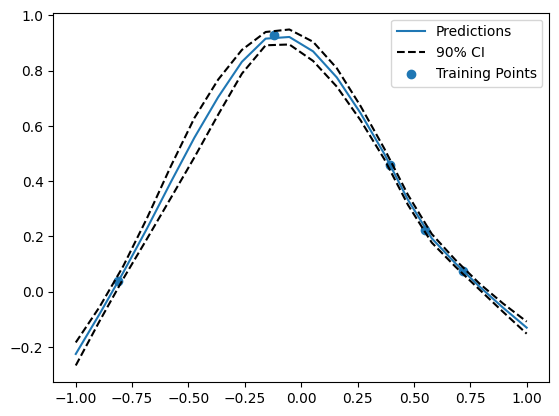

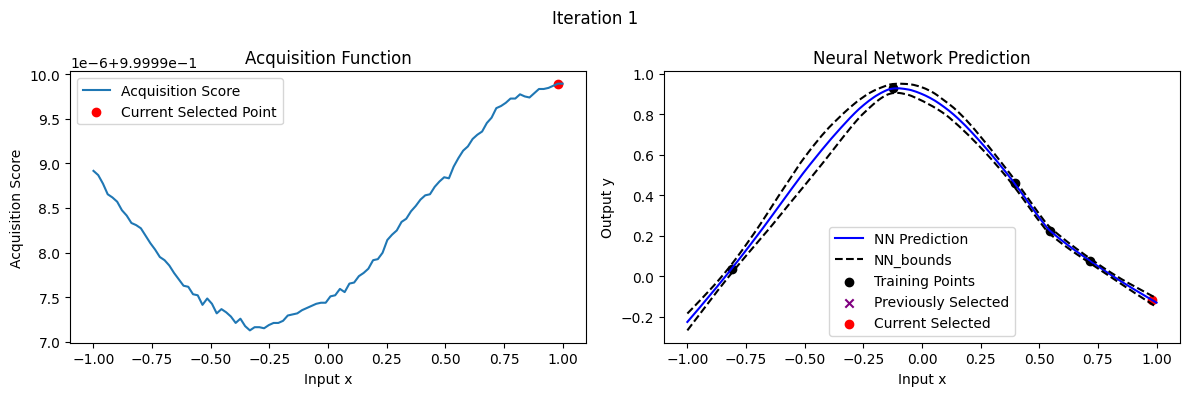

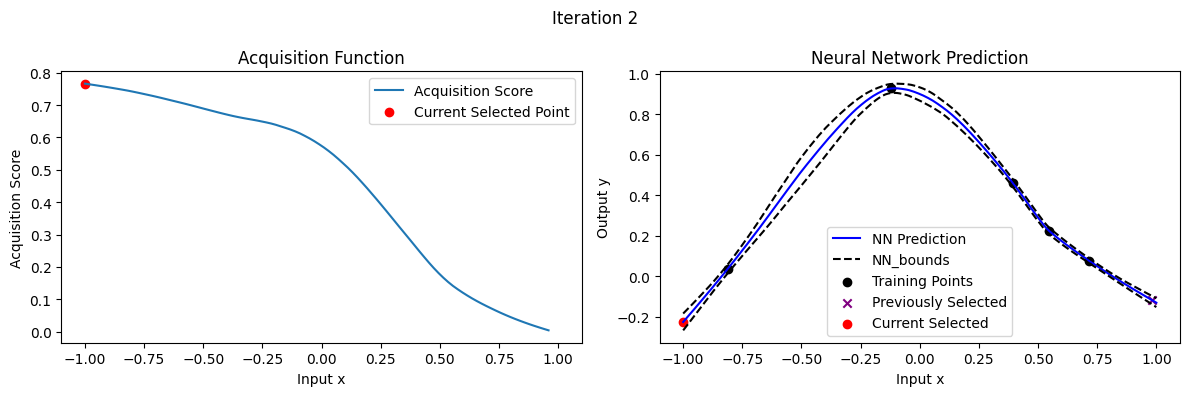

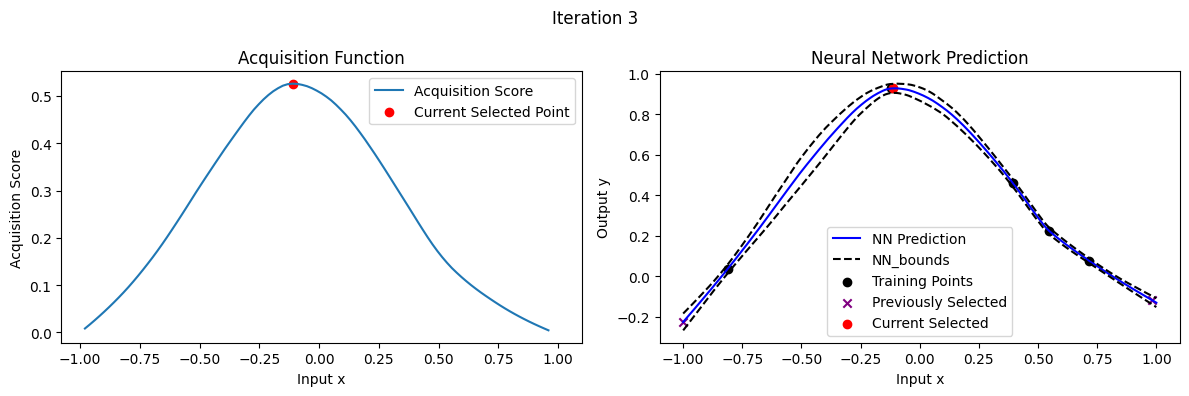

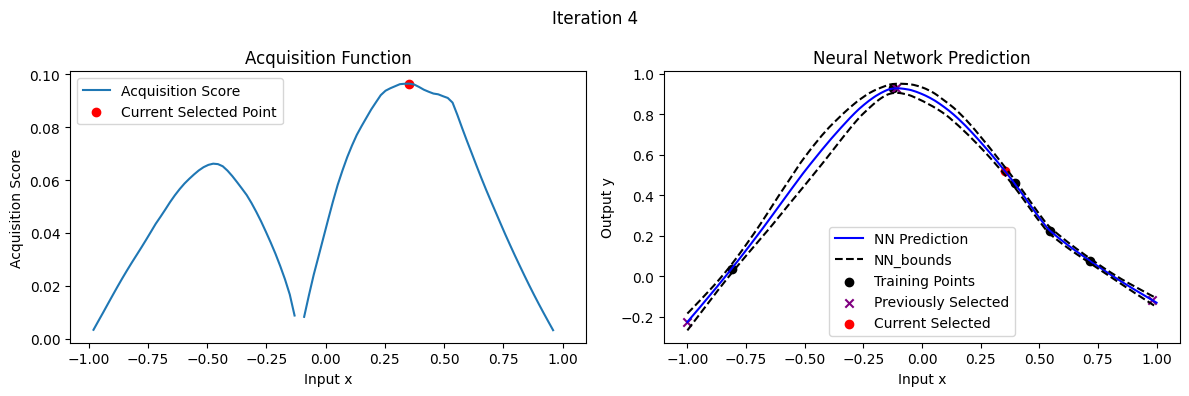

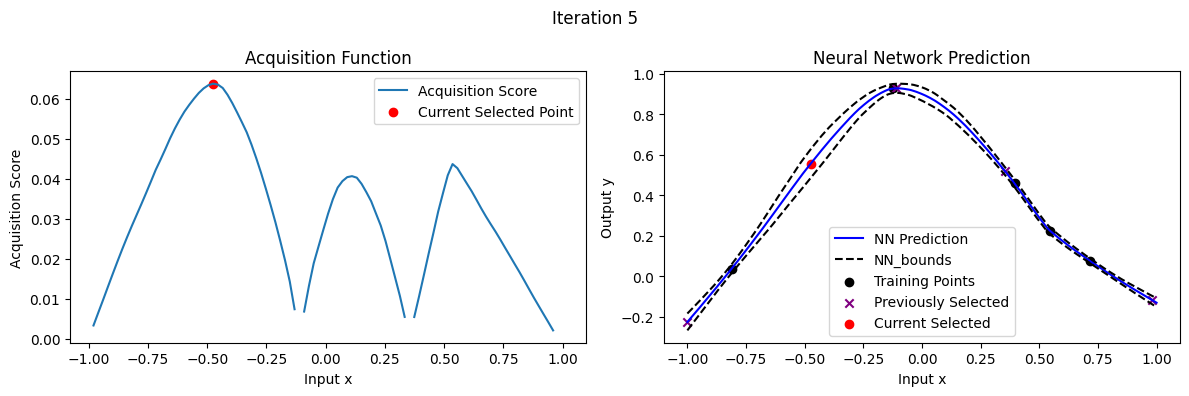

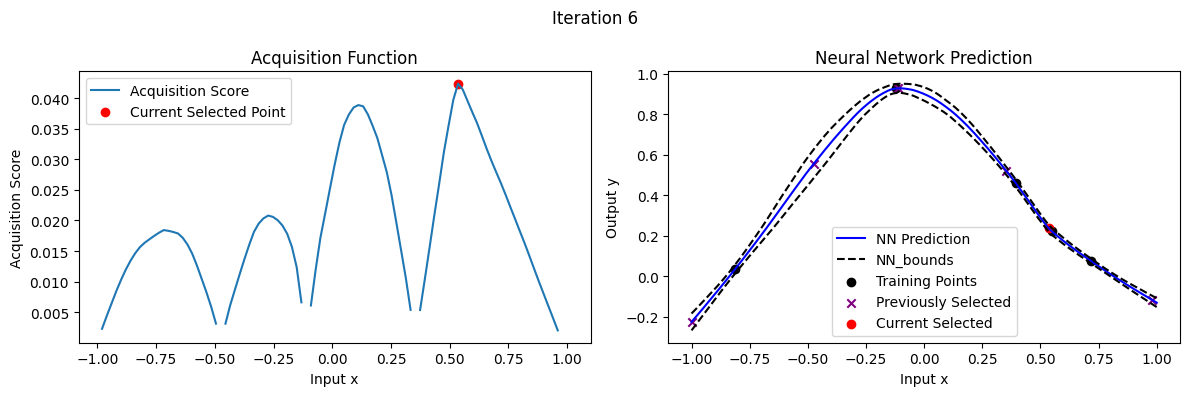

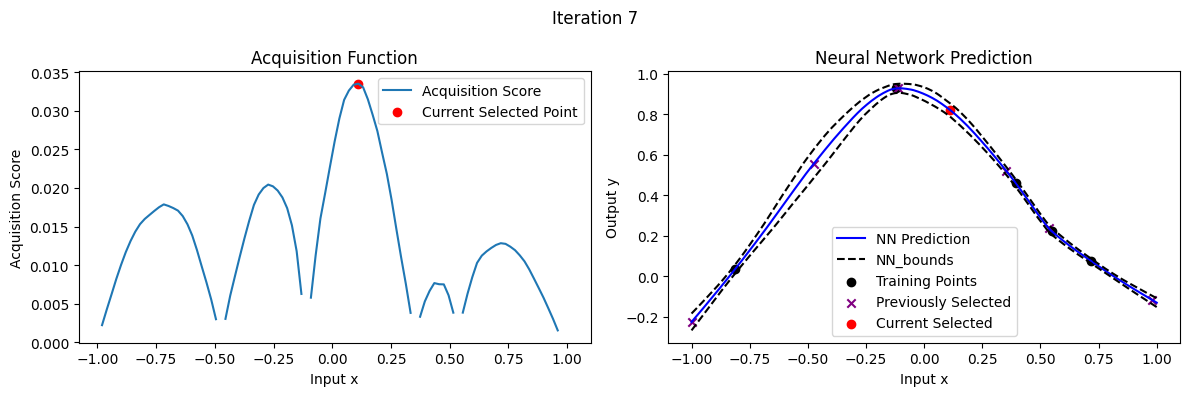

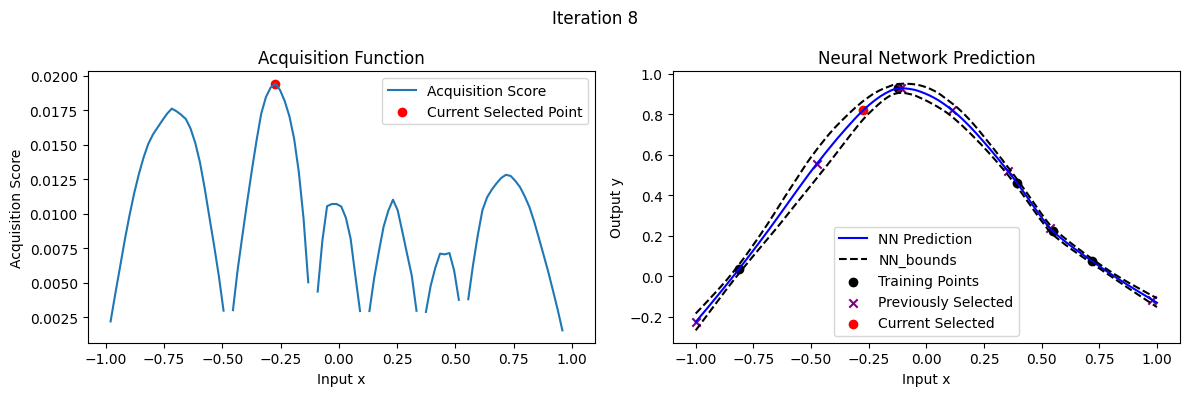

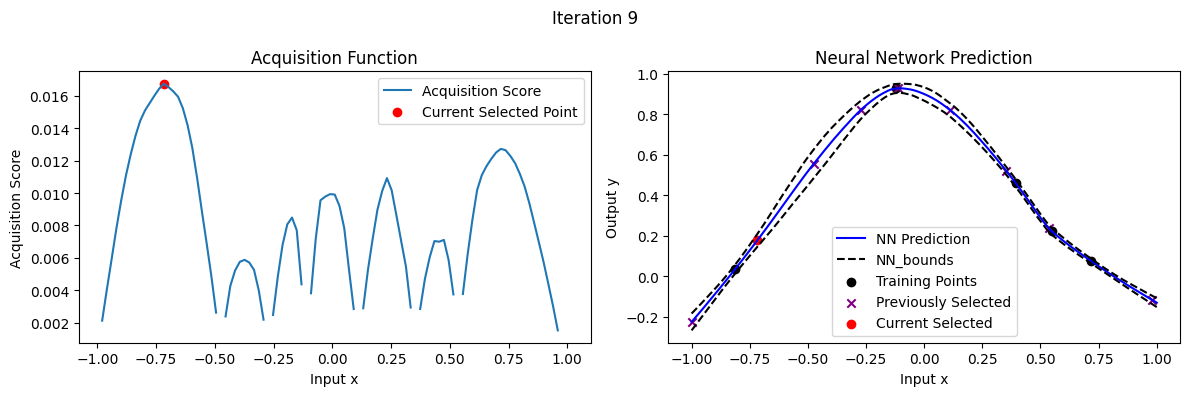

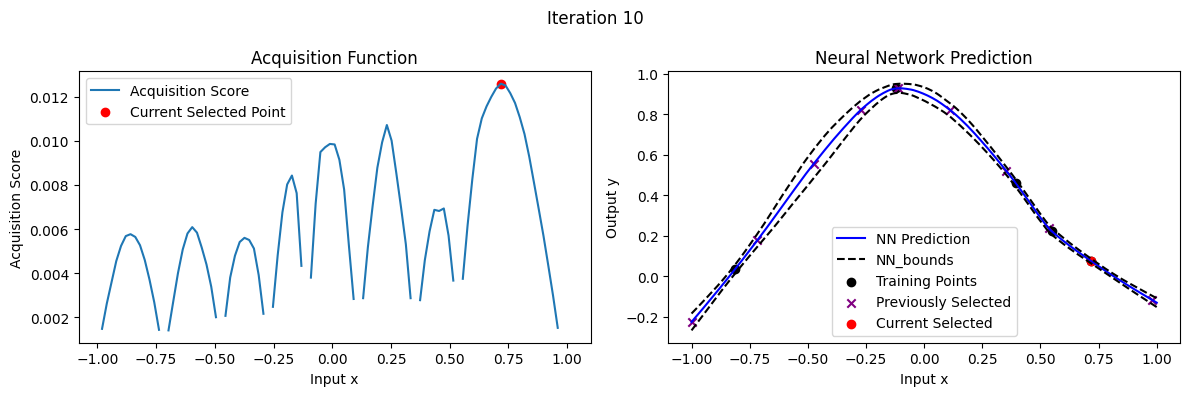

: 

In [7]:
run_adaptive_sampling_round_DE(deep_ens, init_inputs, init_targets)